# Task 7: Principal Component Analysis (PCA)

**Dataset:** Wine dataset (sklearn) — 13 chemical features, 3 wine classes  
**Goal:** Reduce 13 dimensions down to 2-3 principal components and visualise the result.

PCA finds directions in the data (principal components) that capture the most variance. It's useful for visualisation, denoising, and as a preprocessing step before ML models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['class'] = wine.target_names[y]

print(f"Original shape: {X.shape}")
print(f"Features: {wine.feature_names}")
print(f"Classes: {wine.target_names}")

Original shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']


## Standardise the Data

PCA is sensitive to scale. Without standardisation, features with larger ranges (e.g. proline: 0–1000) would dominate the principal components.

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Mean ≈ 0: {X_scaled.mean(axis=0).round(2)}")

Mean ≈ 0: [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]


## Explained Variance Analysis

How many components do we actually need?

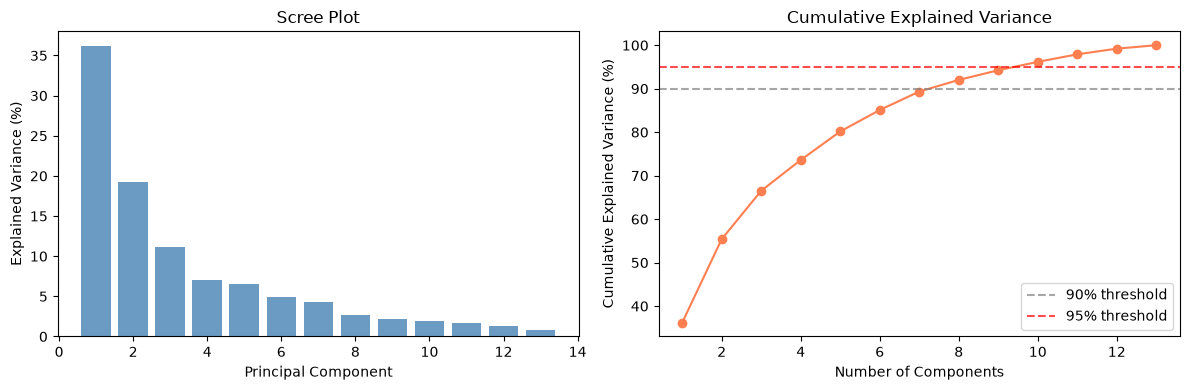

90% variance captured with 8 components
95% variance captured with 10 components


In [3]:
# run PCA with all components first to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# individual explained variance
ax1.bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot')

# cumulative
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 'o-', color='coral')
ax2.axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% threshold')
ax2.axhline(95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig('task7_variance.png', dpi=100)
plt.show()

# show how many components for 90% and 95%
for thresh in [0.90, 0.95]:
    n = np.argmax(cumulative_var >= thresh) + 1
    print(f"{thresh*100:.0f}% variance captured with {n} components")

## Reduce to 2 Components for Visualization

PC1 explains: 36.2%
PC2 explains: 19.2%
Total: 55.4%


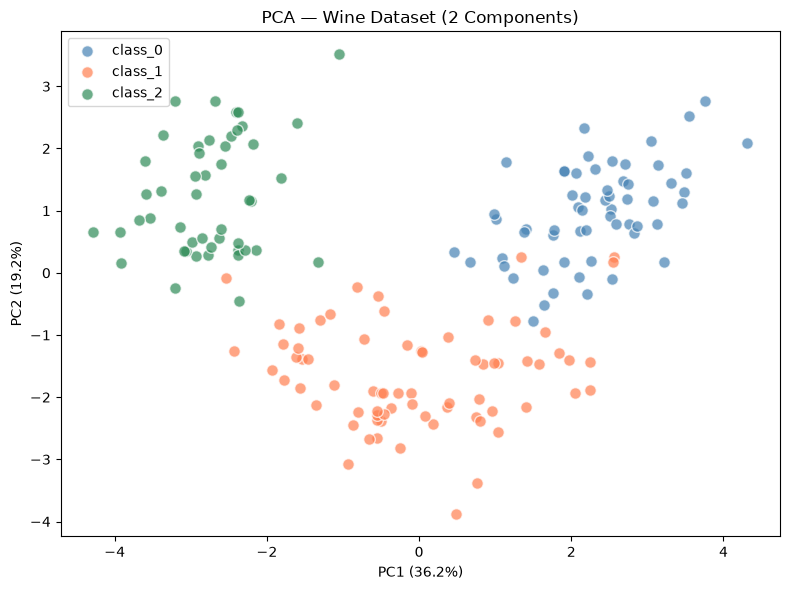

In [4]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

print(f"PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

# scatter the 2D projection
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen']
for i, cls in enumerate(wine.target_names):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=cls, color=colors[i], alpha=0.7, edgecolors='white', s=70)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Wine Dataset (2 Components)')
plt.legend()
plt.tight_layout()
plt.savefig('task7_pca_2d.png', dpi=100)
plt.show()

## 3D PCA Projection

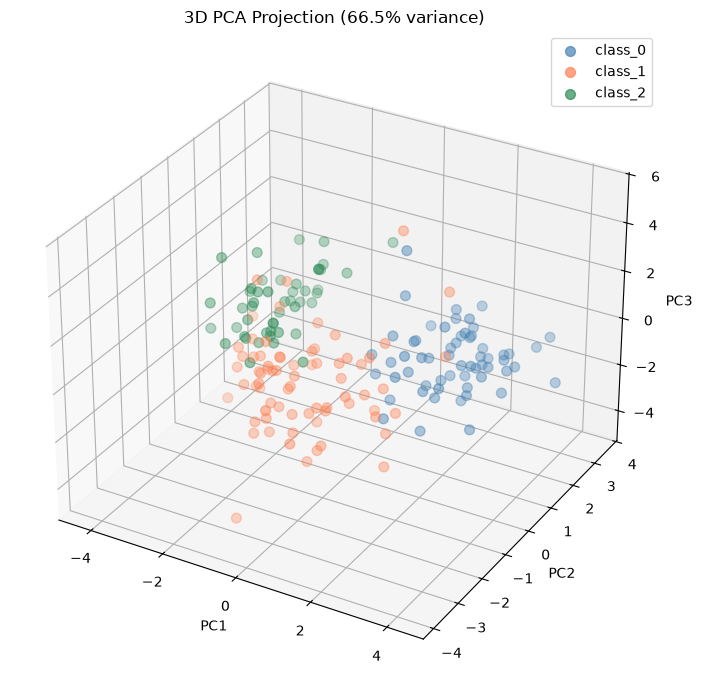

In [5]:
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for i, cls in enumerate(wine.target_names):
    mask = y == i
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               label=cls, color=colors[i], alpha=0.7, s=50)

total_var = pca_3d.explained_variance_ratio_.sum()
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'3D PCA Projection ({total_var*100:.1f}% variance)')
ax.legend()
plt.tight_layout()
plt.savefig('task7_pca_3d.png', dpi=100)
plt.show()

## Loading Plot — What Does PC1 Represent?

In [6]:
# loadings tell us which original features each PC is driven by
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=wine.feature_names,
    columns=['PC1', 'PC2']
).round(3)

print(loadings.sort_values('PC1', key=abs, ascending=False))

                                PC1    PC2
flavanoids                    0.423 -0.003
total_phenols                 0.395  0.065
od280/od315_of_diluted_wines  0.376 -0.164
proanthocyanins               0.313  0.039
nonflavanoid_phenols         -0.299  0.029
hue                           0.297 -0.279
proline                       0.287  0.365
malic_acid                   -0.245  0.225
alcalinity_of_ash            -0.239 -0.011
alcohol                       0.144  0.484
magnesium                     0.142  0.300
color_intensity              -0.089  0.530
ash                          -0.002  0.316


## Summary

- The wine dataset has 13 features, but just **2 principal components capture ~55%** of variance — enough to visually separate the 3 classes.
- With 4 components you get 90%+ variance, which is a good trade-off for downstream ML tasks.
- The three wine classes are well-separated in PC1-PC2 space, suggesting the chemical measurements are highly discriminative.
- PCA is unsupervised — it had no idea about the class labels, yet the projection naturally separates them.